In [1]:
import numpy as np
import matplotlib.pyplot as plt

(array([   0.,  250.,  500.,  750., 1000., 1250., 1500., 1750., 2000.,
        2250., 2500.]),
 [Text(0, 0.0, '0'),
  Text(0, 250.0, '250'),
  Text(0, 500.0, '500'),
  Text(0, 750.0, '750'),
  Text(0, 1000.0, '1000'),
  Text(0, 1250.0, '1250'),
  Text(0, 1500.0, '1500'),
  Text(0, 1750.0, '1750'),
  Text(0, 2000.0, '2000'),
  Text(0, 2250.0, '2250'),
  Text(0, 2500.0, '2500')])

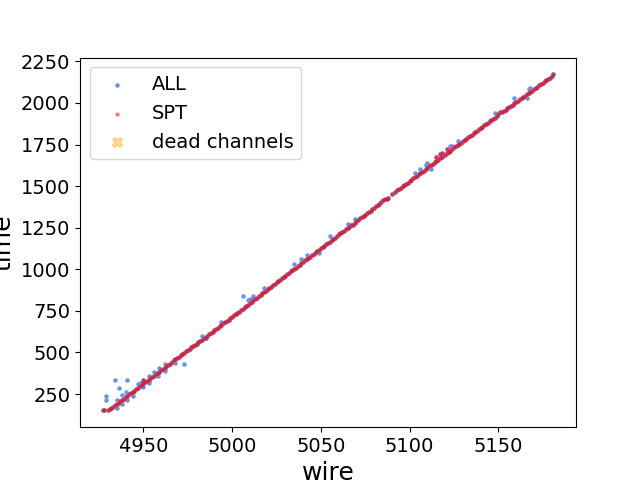

In [2]:
%matplotlib widget
data = np.genfromtxt(
    "inputfile.txt",
    dtype=[
        ('wire',int),
        ('time',float),
        ('hasSPT',int),
        ('inbetween',int),
        ('dead_ch',int),
        ('x',float),
        ('y',float),
        ('z',float)
    ]
)

plt.scatter(data['wire'],data['time'],s=5,color='cornflowerblue',label='ALL')
plt.scatter(data[data['hasSPT']==1]['wire'], data[data['hasSPT']==1]['time'],s=5,marker='X',color='red',alpha=0.4,label='SPT')
#plt.scatter(data[data['inbetween']==0]['wire'], data[data['inbetween']==0]['time'],s=50,color='gray',alpha=0.4,label='outside min/max wire',marker='X')
plt.scatter(data[data['dead_ch']==0]['wire'], data[data['dead_ch']==0]['time'],s=50,color='orange',alpha=0.4,label='dead channels',marker='X')
plt.legend(loc='best',fontsize=14)
plt.xlabel('wire',fontsize=18)
plt.ylabel('time',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.savefig('prova_plot_hit.pdf', format = 'pdf', bbox_inches = 'tight')


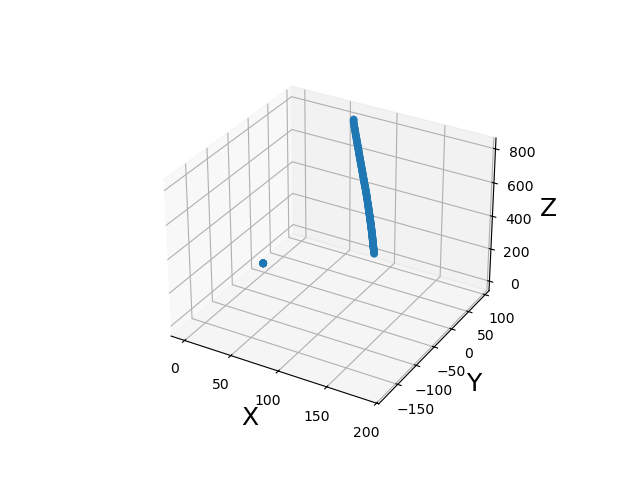

In [3]:
%matplotlib widget
import mplcursors

data = np.genfromtxt(
    "inputfile.txt",
    dtype=[
        ('wire',int),
        ('time',float),
        ('hasSPT',int),
        ('inbetween',int),
        ('dead_ch',int),
        ('x',float),
        ('y',float),
        ('z',float)
    ]
)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(data['x'], data['y'], data['z'])

ax.set_xlabel('X',fontsize=18)
ax.set_ylabel('Y',fontsize=18)
ax.set_zlabel('Z',fontsize=18)

cursor = mplcursors.cursor(sc, hover=True)

@cursor.connect("add")
def on_add(sel):
    idx = sel.index
    sel.annotation.set_text(
        f"wire: {data['wire'][idx]}\n"
        f"x: {data['x'][idx]:.4f}\n"
        f"y: {data['y'][idx]:.4f}\n"
        f"z: {data['z'][idx]:.4f}"
    )

